# The Dataset: `load_breast_cancer`

This is another of scikit-learn's built-in "toy" datasets — commonly used to demonstrate classification and dimensionality reduction techniques on real (not synthetic) tabular data, distinct from the image-based `load_digits` dataset.

## What's in it

- **569 samples**, each representing a single breast mass, derived from a digitized image of a fine needle aspirate (FNA) biopsy.
- **30 numeric features** per sample, all computed from characteristics of the cell nuclei visible in each image — things like:
  - **radius**, **texture**, **perimeter**, **area**, **smoothness**, **compactness**, **concavity**, **symmetry**, **fractal dimension**
  - Each of these 10 base measurements is provided in **3 forms**: its **mean**, its **standard error**, and its **"worst" (largest) value** across the cell nuclei in that image — 10 × 3 = 30 features total.
- A **binary target label** (`target`), encoding the diagnosis:
  - `0` = malignant
  - `1` = benign
- Like `load_digits`, calling `load_breast_cancer()` returns a Bunch object bundling the feature matrix (`data`, shape `(569, 30)`), the labels (`target`, shape `(569,)`), and metadata such as `feature_names` and `target_names`.

## Why this dataset is a useful example here

- **Genuinely high-dimensional and real-world:** 30 features is enough to make a case for dimensionality reduction (much like the 64-pixel digits data, but from an entirely different domain — biomedical measurements instead of images), while still being small enough (569 samples) to run quickly.
- **A real binary classification target:** unlike Iris's 3-class or digit's 10-class labels, this gives a natural 2-class coloring for any 2D embedding (PCA, t-SNE, etc.) — a good test of whether the reduced representation still visually separates malignant from benign cases.
- **Features are on very different scales**, just like the Melbourne housing example (e.g. "area" can be in the hundreds/thousands, while "smoothness" is a small fraction) — making it a natural dataset to revisit the standardization step, since skipping it would let large-scale features like `area` dominate feature-covariance-based methods like PCA.
- **Common benchmark:** because it's small, clean, and has an interpretable real-world question ("can these cell measurements predict malignancy?"), it's one of the most frequently used datasets in ML tutorials for both classification and visualization techniques — likely reused here specifically to show t-SNE succeeding at visually separating the two diagnosis classes based on cluster structure, the same way it separated digit classes.

In [9]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer # https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Import scikit-learn's StandardScaler — a tool for standardizing data
# (subtract each feature's mean, divide by its standard deviation),
# the same operation done manually earlier with
# (X - X.mean(axis=0)) / X.std(axis=0) for the Iris and Melbourne
# examples.
#
# Using StandardScaler instead of the manual formula offers a few
# practical advantages:
#   - It follows the same fit/transform pattern as PCA, MDS, etc.:
#     scaler.fit(X) LEARNS each feature's mean and std from the data,
#     and scaler.transform(X) APPLIES that scaling — which matters
#     when you need to scale new/unseen data using the SAME mean/std
#     learned from training data (e.g. fit on training set, transform
#     both train and test), rather than recomputing a fresh mean/std
#     from whatever data happens to be passed in each time.
#   - It handles edge cases more robustly (e.g. avoiding division-by-
#     zero issues for constant columns) than a raw manual formula.
#
# Given the breast cancer dataset's 30 features on very different
# scales (as flagged in its description — e.g. "area" vs. "smoothness"),
# this import signals that standardization will be applied before
# running PCA and/or t-SNE on this dataset, just as it was for Iris
# and the Melbourne housing data.
from sklearn.preprocessing import StandardScaler

We will use the Breast Cancer dataset which is a built-in dataset in scikit-learn.
It is a binary classification problem where the task is to predict whether a tumor is malignant or benign.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target


The data is split into training and testing sets to evaluate the performance of our model later.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


We create a pipeline with data scaling, PCA for dimensionality reduction to 10 components,
followed by Logistic Regression for classification.

In [4]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10, random_state=42)),
    ('classifier', LogisticRegression(random_state=42))
])

In [5]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('pca', PCA(n_components=10, random_state=42)),
                ('classifier', LogisticRegression(random_state=42))])

For visualization, we create another pipeline with data scaling, PCA, and then t-SNE for 2D visualization.
This will allow us to see how well the transformations separate the data.

In [6]:
visual_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10, random_state=42)),
    ('tsne', TSNE(n_components=2, random_state=42))
])

We plot the 2D projection of the testing data after going through the PCA and t-SNE transformations.
The color of the points corresponds to the true labels, helping to visualize the separation of classes.

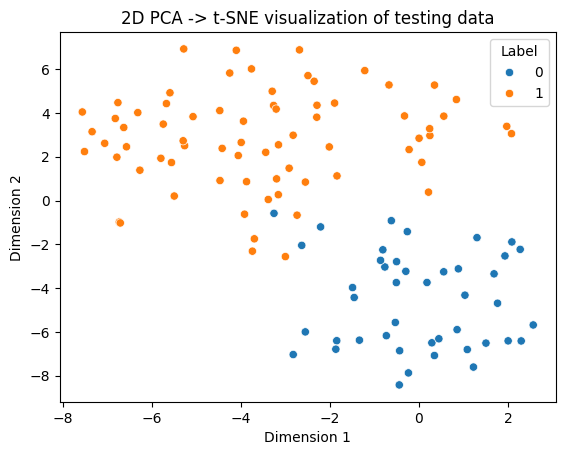

In [7]:
X_test_transformed = visual_pipeline.fit_transform(X_test)

import pandas as pd
import seaborn as sns

data_viz = pd.DataFrame(X_test_transformed, columns=['Dimension 1', 'Dimension 2'])
data_viz['Label'] = y_test

# We use sns.scatterplot to create a scatter plot where the color of the points is determined by the labels in y_test.
sns.scatterplot(data=data_viz, x='Dimension 1', y='Dimension 2', hue='Label')
plt.title('2D PCA -> t-SNE visualization of testing data')
plt.show()